In [1]:
# 自动检查并安装依赖项
import importlib
import subprocess
import sys

def check_and_install(package):
    try:
        importlib.import_module(package)
        print(f"{package} 已安装")
    except ImportError:
        print(f"{package} 未安装，正在安装...")
        # 使用Popen代替check_call以支持实时输出
        process = subprocess.Popen(
            [sys.executable, "-m", "pip", "install", package],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1
        )
        
        # 实时读取并打印输出
        for line in iter(process.stdout.readline, ''):
            print(line.strip())
        
        process.stdout.close()
        process.wait()
        
        if process.returncode == 0:
            print(f"{package} 安装完成")
        else:
            print(f"{package} 安装失败，返回代码 {process.returncode}")

# 检查并安装必要的依赖项
required_packages = ['pandas', 'matplotlib', 'seaborn']
for package in required_packages:
    check_and_install(package)

pandas 已安装
matplotlib 已安装
seaborn 已安装


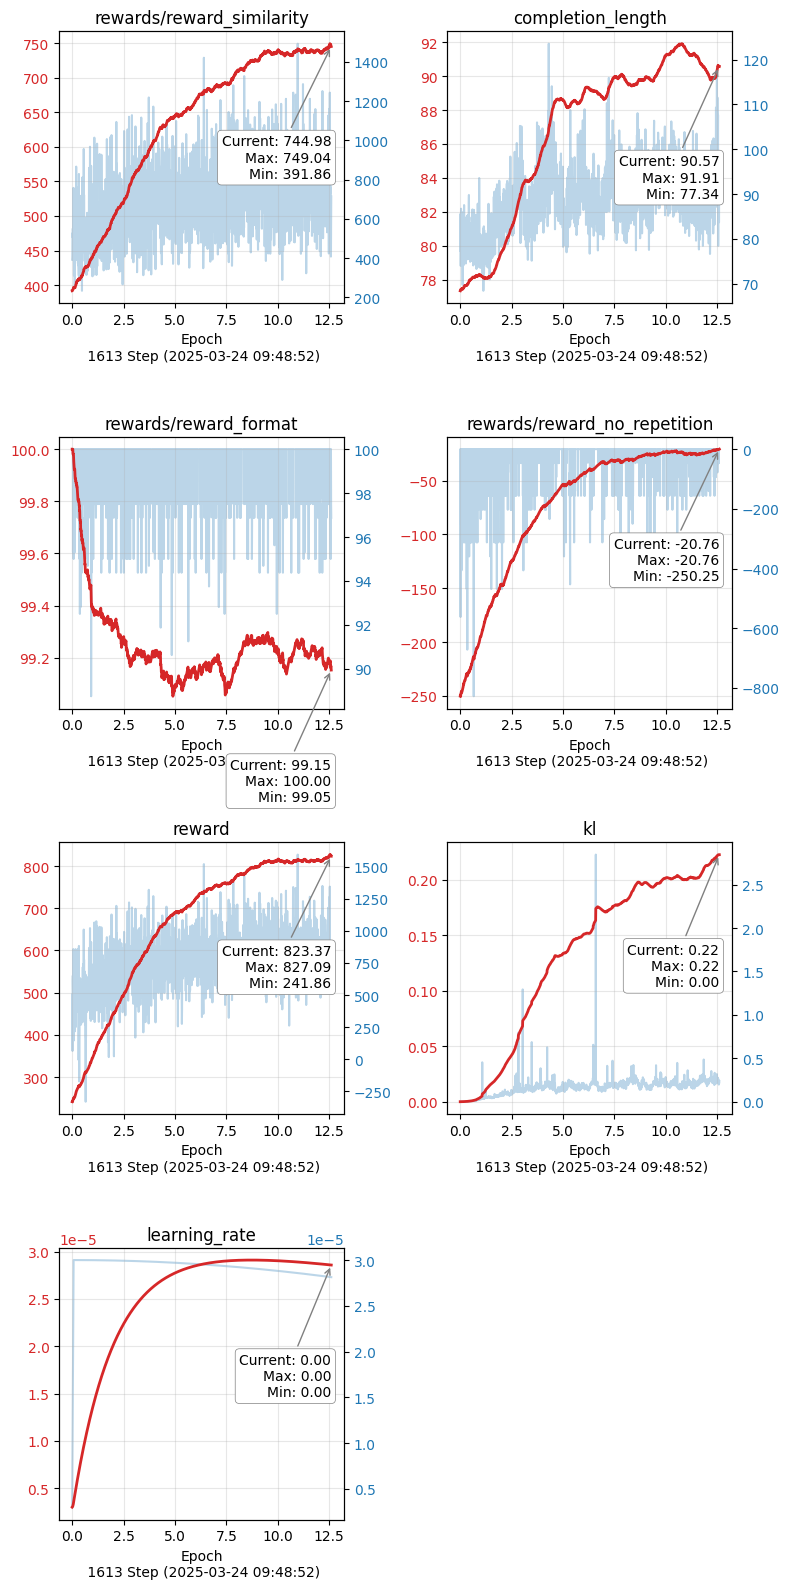

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re
import json
import os
import time
import datetime
from IPython.display import clear_output, display
from math import ceil

# 全局变量记录上次文件状态
last_modified_time = 0
last_log_list = []
# log_file_path = '/root/autodl-fs/mimibot-factory/grpo_log_0323-1.txt'
# log_file_path = '/root/autodl-fs/mimibot-factory/grpo_log_0322-3.txt'
log_file_path = "mimibot_tifa_20250324.txt"

def parse_log_file(file_path):
    """解析日志文件并返回数据和当前修改时间"""
    global last_modified_time
    
    current_modified = os.path.getmtime(file_path)
    if current_modified == last_modified_time:
        return None  # 文件未修改
    
    with open(file_path, 'r') as file:
        log_content = file.read()
    
    new_log_list = []
    for line in log_content.split('\n'):
        match = re.search(r"{'loss': (.*?)}", line)
        if match:
            try:
                match_line = match.group(0).replace('\'', '\"')
                log_dict = json.loads(match_line)
                new_log_list.append(log_dict)
            except json.JSONDecodeError:
                continue
    
    # 只有当数据发生变化时才更新
    if new_log_list != last_log_list:
        last_modified_time = current_modified
        return new_log_list
    return None

def create_figure(log_list):
    """根据日志数据创建图表"""
    current_time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    if not log_list:
        return None

    # 准备数据
    epoch_list = [log['epoch'] for log in log_list]
    step_list = list(range(len(epoch_list)))
    max_epoch = max(epoch_list) if epoch_list else 0
    if step_list:
        epoch_list = [i/len(step_list)*max_epoch for i in step_list]
    else:
        return None

    metrics = [
        'rewards/reward_similarity',
        'completion_length',
        'rewards/reward_format',
        'rewards/reward_no_repetition',
        'reward',
        'kl',
        "learning_rate"
    ]
    data = {metric: [log.get(metric, 0) for log in log_list] for metric in metrics}

    # 数据平滑函数
    def smooth_data(data, window_size=500):
        alpha = 2 / (window_size + 1)  # 将窗口大小转换为指数平滑的alpha参数
        smoothed = []
        prev = data[0]
        for value in data:
            prev = alpha * value + (1 - alpha) * prev
            smoothed.append(prev)
        return smoothed
    
    def smooth_bounds(data, window_size=200):
        upper, lower = [], []
        for i in range(len(data)):
            window = data[max(0, i-window_size):i+1]
            upper.append(max(window) if window else 0)
            lower.append(min(window) if window else 0)
        return upper, lower

    # 创建图表
    num_metrics = len(metrics)
    rows = ceil(num_metrics / 2)
    fig, axs = plt.subplots(rows, 2, figsize=(8, 4*rows))
    if rows == 1:
        axs = axs.reshape(1, -1)
    axs = axs.flatten()

    # 绘制每个子图
    for i, metric in enumerate(metrics):
        ax1 = axs[i]
        ax2 = ax1.twinx()
        
        # 处理数据
        smoothed = smooth_data(data[metric])
        upper, lower = smooth_bounds(data[metric])
        last_value = smoothed[-1] if smoothed else 0

        # 设置颜色
        color_original = 'tab:blue'
        color_smoothed = 'tab:red'

        # 绘制曲线
        ax1.plot(epoch_list, smoothed, color=color_smoothed, linewidth=2, label='Smoothed')
        ax2.plot(epoch_list, data[metric], color=color_original, alpha=0.3, label='Original')

        # 设置子图元素
        ax1.set_title(metric)
        ax1.set_xlabel(f'Epoch\n {step_list[-1]} Step ({current_time})')
        # ax1.set_ylabel('Smoothed', color=color_smoothed)
        # ax2.set_ylabel('Original', color=color_original)
        ax1.tick_params(axis='y', labelcolor=color_smoothed)
        ax2.tick_params(axis='y', labelcolor=color_original)
        ax1.grid(True, alpha=0.3)

        # 添加标注
        if epoch_list and smoothed:
            bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5)
            ax1.annotate(f'Current: {last_value:.2f}\nMax: {max(smoothed):.2f}\nMin: {min(smoothed):.2f}',
                        xy=(epoch_list[-1], last_value),
                        xytext=(0, -80), textcoords='offset points',
                        bbox=bbox_props,
                        ha='right', va='center',
                        arrowprops=dict(arrowstyle="->", color='gray'))

        ax1.set_zorder(ax2.get_zorder() + 1)  # 确保ax1在ax2上层
        ax1.patch.set_visible(False)  # 隐藏ax1的背景
        # 合并图例
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        # ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    # 隐藏多余子图
    for j in range(num_metrics, len(axs)):
        axs[j].set_visible(False)

    plt.tight_layout()
    return fig

# 主循环
while True:
    try:
        new_data = parse_log_file(log_file_path)
        if new_data:
            clear_output(wait=True)
            last_log_list = new_data
            fig = create_figure(last_log_list)
            if fig:
                display(fig)
                plt.close(fig)
        time.sleep(1)  # 缩短检测间隔到1秒
    except Exception as e:
        print(f"监控异常: {str(e)}")
        time.sleep(5)
    except KeyboardInterrupt:
        print("监控已终止")
        break

import json

# Load the dataset
try:
    with open('data/alpaca_data_processed.json', 'r', encoding='utf-8') as f:
        dataset = json.load(f)
    
    # Extract reward values from log_list
    reward_values = [log['rewards/reward_similarity'] for log in log_list]
    
    # Check if the length of reward_values matches the dataset length
    if len(dataset) != len(reward_values):
        print(f"Warning: Dataset size ({len(dataset)}) doesn't match reward values size ({len(reward_values)})")
        print("Will use available rewards and truncate as needed")
    
    # Add reward field to each item in the dataset
    for i, item in enumerate(dataset):
        if i < len(reward_values):  # Ensure we don't go out of bounds
            item['reward'] = reward_values[i]
        else:
            print(f"No reward value for item {i}")
            break
    
    # Save modified dataset
    with open('data/alpaca_data_reward.json', 'w', encoding='utf-8') as f:
        json.dump(dataset, f, ensure_ascii=False, indent=2)
    
    print(f"Dataset with rewards saved to data/alpaca_data_reward.json")
    print(f"Added rewards to {min(len(dataset), len(reward_values))} items")
except Exception as e:
    print(f"Error processing dataset: {e}")

import json

# Load the dataset with rewards
try:
    with open('data/alpaca_data_reward.json', 'r', encoding='utf-8') as f:
        dataset = json.load(f)
    
    print(f"Loaded dataset with {len(dataset)} items")
    
    # Filter to keep only items with reward field
    filtered_dataset = [item for item in dataset if 'reward' in item]
    print(f"Filtered dataset has {len(filtered_dataset)} items with reward field")
    
    # Sort the dataset by reward in descending order
    sorted_dataset = sorted(filtered_dataset, key=lambda x: x['reward'], reverse=True)
    
    # Save the sorted dataset
    with open('data/alpaca_data_reward_sort.json', 'w', encoding='utf-8') as f:
        json.dump(sorted_dataset, f, ensure_ascii=False, indent=2)
    
    print(f"Sorted dataset saved to data/alpaca_data_reward_sort.json")
    print(f"Top 5 rewards: {[item['reward'] for item in sorted_dataset[:5]]}")
    
except Exception as e:
    print(f"Error processing dataset: {e}")